- Author: Yousef Al Zeer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive' , force_remount=True)

Mounted at /content/drive


In [ ]:
fpath = "/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/Data/insurance.csv"
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Explore Data

In [ ]:
duplicated_rows = df.duplicated(keep=False)
df[duplicated_rows]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [ ]:
df.describe(include='O')


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## 4. Train-Test Split

In [ ]:
X = df.drop(columns='charges')
y = df['charges']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Category PreProcessing

- No need to impute since no missing values
- One-hot encoding needed

In [ ]:
cat_selector = make_column_selector(dtype_include='object')
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_tuple = ('categorical', ohe , cat_selector)
cat_tuple

('categorical',
 OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 <sklearn.compose._column_transformer.make_column_selector at 0x7d33bf3cdeb0>)

## Numeric PreProcessing

In [ ]:
num_selector = make_column_selector(dtype_include='number')
scaler = StandardScaler()
num_tuple = ('numeric' , scaler , num_selector)
num_tuple

('numeric',
 StandardScaler(),
 <sklearn.compose._column_transformer.make_column_selector at 0x7d33bef8ce90>)

## ColumnTransformer

In [ ]:
preprocessor = ColumnTransformer([cat_tuple, num_tuple],verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bf3cdeb0>),
                                ('numeric', StandardScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bef8ce90>)],
                  verbose_feature_names_out=False)

## 5. Create a Model Pipeline

In [ ]:
linreg = LinearRegression()
linreg_pipe = make_pipeline(preprocessor, linreg)
linreg_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bf3cdeb0>),
                                                 ('numeric', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bef8ce90>)],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [ ]:
linreg_pipe.fit(X_train , y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bf3cdeb0>),
                                                 ('numeric', StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d33bef8ce90>)],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

## 6. Evaluate the Model

In [ ]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics


def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,output_dict=output_frame,label='Test Data' )



  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

In [ ]:
evaluate_regression(linreg_pipe , X_train , y_train , X_test , y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 4,207.729
- MSE = 37,182,190.657
- RMSE = 6,097.720
- R^2 = 0.730

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 4,069.039
- MSE = 35,283,922.771
- RMSE = 5,940.027
- R^2 = 0.796


## 7. Interpretation

### Mean Absolute Error (MAE)

- On average, the model's predictions are $4,069 off the actual price.

### Mean Squared Error (MSE)

- On average, the model is incorrect by 35.2m square units.

### Root Mean Squared Error (RMSE)

- On average, the model is incorrect by $5,940

#### Coefficient of R2

- The model performs better on testing data (0.79 V 0.73)

We can Say this:

   - Based on the provided features (X), the model can explain 79.6% of the variation in charges.

   - The model's predictions are incorrect by an average of 4,069 and this error reaches $5,940 when large errors are taken into account, meaning the model struggles somewhat in predicting rare/ high cost cases

   - No signs of overfitting

## 8. Extra Evaluation

Text(0.5, 1.0, 'Residuals by Smoker')

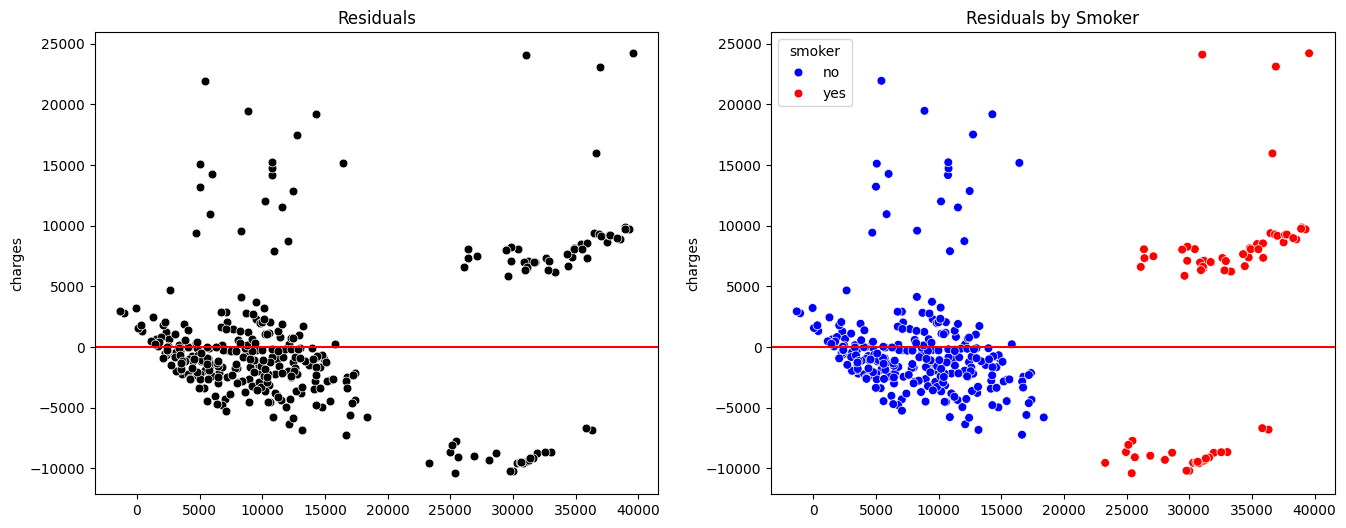

In [ ]:
y_test_pred = linreg_pipe.predict(X_test)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(nrows=1,ncols= 2, figsize=(16, 6))

sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[0], color='black', s=40)
axes[0].axhline(y=0, color='red')
axes[0].set_title('Residuals')

sns.scatterplot(x=y_test_pred, y=residuals, hue=X_test['smoker'], palette={'yes': 'red', 'no': 'blue'},ax=axes[1], s=40)
axes[1].axhline(y=0, color='red')
axes[1].set_title('Residuals by Smoker') ;



Figure illustrates the metrics we obtained. We observe:

- The model performs well in predicting charges for most non smokers, though it underestimates charges for some cases where actual charges exceed predictions.

- The model struggles with smokers, splitting them into 2 distinct groups: one group where charges are underestimated (actual > predicted), and another where charges are overestimated (predicted > actual) .